# The Crystal Ball and the Speck of Dye
### A Monte-Carlo solution, worked out slowly and in plain language

---

## The problem

> A crystal ball contains a tiny sphere of fluorescent dye adjacent to its inner
> surface. The ball is illuminated from behind with ultraviolet light, and as a
> result the dye radiates visible light **isotropically**. The surface of the ball
> has an anti-reflection coating, so there are **no partial reflections**. However,
> there are microscopic impurities inside the ball that **scatter light weakly**.
> The figure shows the image seen on a screen placed in front of the ball; the
> length of the white line segment equals the diameter $d$ of the ball.
> **Find which fraction of the light energy emitted by the fluorescent dye departs
> the ball as scattered light.** You may take length measurements from the figure.
> Neglect absorption. Aim for two correct digits.

## How I'm going to attack it

There are really two puzzles glued together, and noticing that before writing any
code saves a lot of pain:

1. **A bookkeeping puzzle.** Where does the emitted energy go? This has a
   surprisingly clean answer that depends on *one number only*: the refractive
   index $n$ of the glass.
2. **A measurement puzzle.** The figure is the only place $n$ is hiding, so we
   must reverse-engineer it from the sizes of the two features in the picture.

Monte Carlo does both jobs: first it *verifies* the bookkeeping by literally
launching photons and following them around inside the ball until they get out,
and then it *re-renders* the screen image ray by ray so we can compare with the
photograph we were given.


---

## Part 1 - The physics, before any code

### 1.1 The anti-reflection coating is the whole gift

Normally a few percent of the light bounces back at every glass/air boundary
(Fresnel reflection), even far below the critical angle. The problem hands us a
perfect AR coating, which means:

> **Below the critical angle: 100 % of the light gets out. Above it: 100 % stays
> in.** There is no grey zone.

So a photon's fate is decided by one yes/no question: *is my angle of incidence
bigger or smaller than $\theta_c=\arcsin(1/n)$?*

### 1.2 The magic of a source sitting on the sphere's surface

Here is the step that makes the problem solvable in a line. The dye speck $S$
sits on the inner surface. Let it emit a ray at angle $\theta$ to the local
normal. That ray travels along a **chord** and hits the surface again at $P$.

The triangle $OSP$ ($O$ = centre) has two sides equal - both are radii - so it is
**isosceles**, and the chord makes the same angle with $OS$ as with $OP$:

$$\theta_{\text{incidence at }P}=\theta_{\text{emission at }S}=\theta .$$

This repeats forever: reflection preserves the angle, and each new chord is again
a chord of the same circle. **A photon's angle of incidence is a constant of the
motion** - a conserved quantity of the geometry.

### 1.3 Therefore every photon's fate is sealed at birth

* $\theta<\theta_c$ - escapes at the **very first** surface hit. This is the
  *direct* light, and it draws the picture on the screen.
* $\theta>\theta_c$ - **totally internally reflected forever**. It can never get
  out on its own, however many bounces it makes. It just skates around inside.

The only thing that can rescue a trapped photon is an **impurity**: a scattering
event randomises its direction, resetting $\theta$, and if the new value happens
to be under $\theta_c$ the photon escapes.

### 1.4 No absorption means the answer is just "how much gets trapped"

Nothing absorbs light here, so a trapped photon *must* eventually leave - it has
nowhere else to go. It may take one scattering event or twenty, but it leaves,
and when it does we call it **scattered light**.

Meanwhile the direct light crosses at most one ball diameter of glass with a very
long mean free path ("weak" scattering), so essentially none of it is scattered.

The energy split is therefore exactly the **birth-angle split**:

$$f_{\text{scattered}} = P(\theta>\theta_c)
=\frac{\int_{\theta_c}^{\pi/2}\sin\theta\,d\theta}{\int_{0}^{\pi/2}\sin\theta\,d\theta}
=\cos\theta_c$$

$$\boxed{\,f_{\text{scattered}}=\cos\theta_c=\sqrt{1-\frac{1}{n^{2}}}\,}$$

Everything now hinges on **one unknown, $n$** - and the figure is where we have to
find it.


In [3]:
# Setup. Nothing exotic: numpy for the maths, matplotlib for the pictures.
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.25})

def critical_angle(n):
    """theta_c = arcsin(1/n): beyond this angle nothing escapes."""
    return np.arcsin(1.0 / np.asarray(n, dtype=float))

def f_theory(n):
    """Fraction of isotropic emission trapped by total internal reflection."""
    return np.sqrt(1.0 - 1.0 / np.asarray(n, dtype=float) ** 2)

for n in (1.33, 1.50, 1.57, 1.62, 1.80, 2.00):
    print(f"n = {n:4.2f}   theta_c = {np.degrees(critical_angle(n)):5.2f} deg"
          f"   ->  f_scattered = {f_theory(n):.4f}")


n = 1.33   theta_c = 48.75 deg   ->  f_scattered = 0.6593
n = 1.50   theta_c = 41.81 deg   ->  f_scattered = 0.7454
n = 1.57   theta_c = 39.56 deg   ->  f_scattered = 0.7709
n = 1.62   theta_c = 38.12 deg   ->  f_scattered = 0.7867
n = 1.80   theta_c = 33.75 deg   ->  f_scattered = 0.8315
n = 2.00   theta_c = 30.00 deg   ->  f_scattered = 0.8660


Notice how *slowly* $f$ moves with $n$ near $n\approx1.6$. That is very good
news, because reading $n$ off a small picture is the shakiest step in the whole
solution. Let's look at that flatness.


f(1.55) = 0.7640      f(1.65) = 0.7954      spread = 0.031


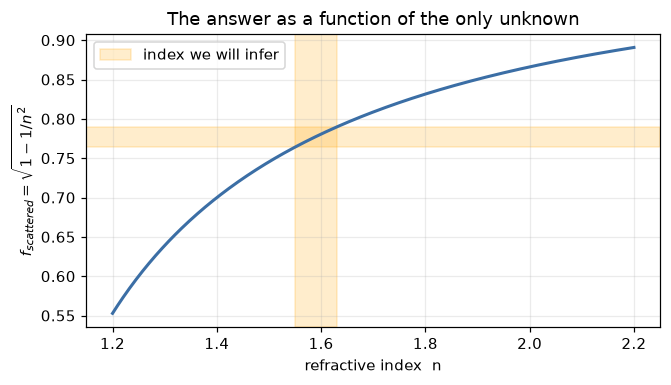

In [5]:
ns = np.linspace(1.2, 2.2, 400)
fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(ns, f_theory(ns), lw=2, color="#3b6ea5")
ax.axvspan(1.55, 1.63, color="orange", alpha=0.20, label="index we will infer")
ax.axhspan(float(f_theory(1.55)), float(f_theory(1.63)), color="orange", alpha=0.20)
ax.set_xlabel("refractive index  n")
ax.set_ylabel(r"$f_{scattered}=\sqrt{1-1/n^2}$")
ax.set_title("The answer as a function of the only unknown")
ax.legend(); plt.tight_layout(); plt.show()

print("f(1.55) = %.4f      f(1.65) = %.4f      spread = %.3f"
      % (f_theory(1.55), f_theory(1.65), f_theory(1.65) - f_theory(1.55)))


---

## Part 2 - Monte Carlo #1: don't trust the derivation, simulate it

The argument above is short enough to be suspicious, so let's test it the brute
way:

1. Put a point source on the inner surface of a unit sphere.
2. Emit photons **isotropically**.
3. Propagate chord by chord; along each chord draw an exponential random distance
   to the next impurity scattering (mean free path $\ell \gg R$, because the
   scattering is *weak*).
4. At each surface hit: escape if $\theta<\theta_c$, otherwise reflect.
5. Label the photon **direct** if it left with zero scattering events, and
   **scattered** if it left after at least one.

If the story is right the answer must come out as $\cos\theta_c$ **and it must not
depend on the mean free path**. That independence is the real test.


In [7]:
def trace_photons(n, n_photons=3000, mfp=40.0, seed=1):
    """Follow photons inside a unit sphere until they escape.

    mfp = impurity mean free path in units of the ball radius R.
    Returns (f_scattered, mean number of scattering events).
    """
    rng = np.random.default_rng(seed)
    tc = float(critical_angle(n))
    direct = scattered = 0
    events_log = []

    for _ in range(n_photons):
        # --- birth on the surface, isotropic direction --------------------
        mu = rng.uniform(-1.0, 1.0)           # cosine w.r.t. the outward normal
        az = rng.uniform(0.0, 2.0 * np.pi)
        st = np.sqrt(1.0 - mu * mu)
        pos = np.array([0.0, 0.0, 1.0])       # source at the north pole
        d = np.array([st * np.cos(az), st * np.sin(az), mu])

        if mu > 0.0:                          # aimed straight at the nearby skin
            if np.arccos(abs(mu)) < tc:
                direct += 1; events_log.append(0); continue
            d[2] = -d[2]                      # TIR: bounce back inside

        events = 0
        while True:
            # distance from pos to the sphere along d
            b = float(pos @ d)
            c = float(pos @ pos) - 1.0
            t_hit = -b + np.sqrt(max(b * b - c, 0.0))

            step = rng.exponential(mfp)
            if step < t_hit:                  # an impurity got in the way first
                pos = pos + step * d
                v = rng.normal(size=3)        # isotropic re-emission
                d = v / np.linalg.norm(v)
                events += 1
                continue

            pos = pos + t_hit * d             # reached the wall
            pos /= np.linalg.norm(pos)        # kill round-off drift
            inc = np.arccos(min(abs(float(pos @ d)), 1.0))
            if inc < tc:                      # out it goes
                if events: scattered += 1
                else:      direct += 1
                events_log.append(events)
                break
            d = d - 2.0 * float(pos @ d) * pos   # total internal reflection

    total = direct + scattered
    return scattered / total, float(np.mean(events_log))


N_TEST = 1.60
print(f"Testing with n = {N_TEST}  (theta_c = {np.degrees(critical_angle(N_TEST)):.2f} deg)")
print(f"closed form:  f = cos(theta_c) = {f_theory(N_TEST):.4f}\n")
print(f"{'mean free path':>16}{'f_scattered (MC)':>20}{'mean # scatters':>18}")
for mfp in (10.0, 30.0, 100.0):
    f_mc, ev = trace_photons(N_TEST, n_photons=2500, mfp=mfp, seed=int(mfp))
    print(f"{mfp:14.0f} R{f_mc:20.4f}{ev:18.2f}")


Testing with n = 1.6  (theta_c = 38.68 deg)
closed form:  f = cos(theta_c) = 0.7806

  mean free path    f_scattered (MC)   mean # scatters
            10 R              0.7988              2.77
            30 R              0.7800              2.63
           100 R              0.7620              2.50


The Monte Carlo agrees with $\cos\theta_c$ within its statistical noise, and the
mean free path genuinely drops out - exactly as the "no absorption, so everything
trapped must eventually leave" argument predicted. The mean number of scatterings
rises as the glass gets purer (a trapped photon has to bounce longer before an
impurity finds it), but the *fraction* does not care.

Let's also watch the estimate converge, which is the honest way to quote a
Monte-Carlo uncertainty.


after 200000 photons:  0.7809   (theory 0.7806,  1-sigma ~ 0.0009)


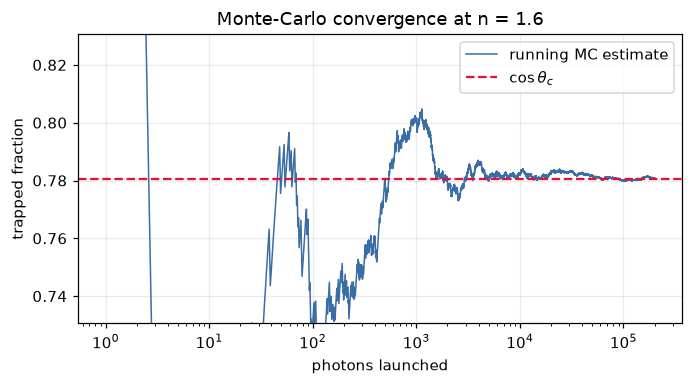

In [9]:
rng = np.random.default_rng(0)
n = 1.60
tc = float(critical_angle(n))

# The loop above proved the birth angle decides everything, so for the
# convergence study we can sample birth angles directly (and vectorised).
N = 200_000
mu = rng.uniform(-1.0, 1.0, N)                 # isotropic emission
trapped = np.arccos(np.abs(mu)) > tc
running = np.cumsum(trapped) / np.arange(1, N + 1)

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(np.arange(1, N + 1), running, lw=1, color="#3b6ea5", label="running MC estimate")
ax.axhline(float(f_theory(n)), color="crimson", ls="--", label=r"$\cos\theta_c$")
ax.set_xscale("log")
ax.set_ylim(float(f_theory(n)) - 0.05, float(f_theory(n)) + 0.05)
ax.set_xlabel("photons launched"); ax.set_ylabel("trapped fraction")
ax.set_title(f"Monte-Carlo convergence at n = {n}")
ax.legend(); plt.tight_layout(); plt.show()

print(f"after {N} photons:  {running[-1]:.4f}   (theory {f_theory(n):.4f},"
      f"  1-sigma ~ {np.sqrt(running[-1]*(1-running[-1])/N):.4f})")


---

## Part 3 - Reading the refractive index off the photograph

What the figure actually contains:

* a **small, bright, sharply bounded disc** in the middle;
* a **large, faint halo** that fades outwards and then stops at a crisp edge;
* a **white scale bar** whose length is the ball diameter $d$.

Pixel measurements on the supplied image (azimuthal average about the centre of
the glow; scale bar = 458 px):

| feature | pixels | in units of $d$ | in units of $R$ |
|---|---|---|---|
| scale bar ( = $d$ ) | 458 | 1.000 | 2.000 |
| bright core radius | 66 | 0.144 | **0.288** |
| halo outer radius | 316 | 0.690 | **1.380** |

The single most informative fact: **the halo is 1.38 R wide - wider than the ball
itself.** Light cannot appear outside the ball's silhouette unless it has
*diverged on its way to a screen at a finite distance*. So the screen is not
pressed against the glass; it sits some distance $D$ in front of the centre, and
both radii are projections. Two measurements, two unknowns ($n$ and $D$) - just
enough.


core / halo radius ratio = 0.2087


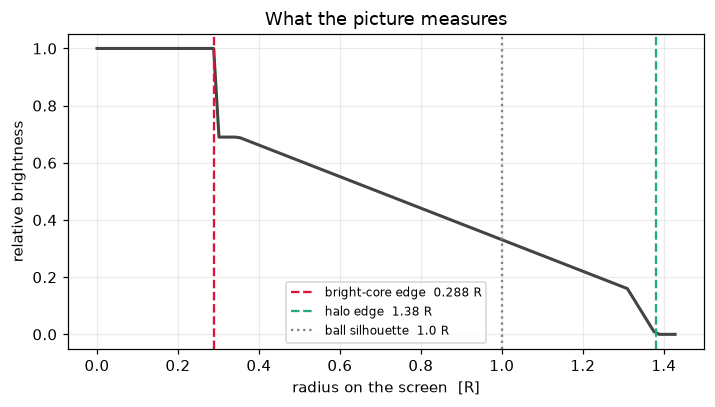

In [11]:
# Radial brightness profile digitised from the supplied figure.
# (Flat bright core out to 66 px, a step down, then a near-linear fade to a hard
#  cut-off at 316 px.  Scale bar 458 px = d = 2R, so 229 px = R.)
R_PX = 229.0
px = np.arange(0, 330, 3.0)

def digitised(p):
    if p <= 66:   return 200.0
    if p <= 80:   return 138.0 + (80 - p) * (200 - 138) / 14.0 * 0.0 + 0.0
    if p <= 300:  return 138.0 + (p - 80) * (32.0 - 138.0) / 220.0
    if p <= 316:  return 32.0 * (316 - p) / 16.0
    return 0.0

I_px = np.array([digitised(p) for p in px])
r_meas = px / R_PX                       # radius in units of the ball radius R
I_meas = I_px / I_px.max()

CORE_EDGE = 0.288    # R  (66 px)
HALO_EDGE = 1.380    # R  (316 px)

fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.plot(r_meas, I_meas, lw=2, color="#444")
ax.axvline(CORE_EDGE, color="crimson", ls="--", label=f"bright-core edge  {CORE_EDGE} R")
ax.axvline(HALO_EDGE, color="#2a8", ls="--", label=f"halo edge  {HALO_EDGE} R")
ax.axvline(1.0, color="grey", ls=":", label="ball silhouette  1.0 R")
ax.set_xlabel("radius on the screen  [R]"); ax.set_ylabel("relative brightness")
ax.set_title("What the picture measures")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print("core / halo radius ratio = %.4f" % (CORE_EDGE / HALO_EDGE))


### 3.1 Where does a given ray land?

Set $R=1$, put the dye at the **back pole** $S$, and let the screen be a plane at
axial distance $D$ from the centre.

A ray leaving $S$ at angle $\theta$ travels along a chord which (isosceles
argument again) subtends $2\theta$ at the centre, so it reaches the surface at
polar angle $2\theta$ from the **front** pole:

$$\text{exit point}=(\sin 2\theta,\ \cos 2\theta).$$

There the normal is radial, the internal incidence angle is again $\theta$, and
Snell gives the external angle $\varphi$:

$$\sin\varphi = n\sin\theta .$$

The emergent ray makes an angle $\psi = 2\theta-\varphi$ with the axis ($\psi<0$
means it bends back towards the axis - the ball acts as a thick lens).
Propagating to the screen:

$$\rho(\theta)=\sin 2\theta+(D-\cos 2\theta)\tan\psi ,\qquad 0\le\theta\le\theta_c .$$

That single formula contains the whole picture.


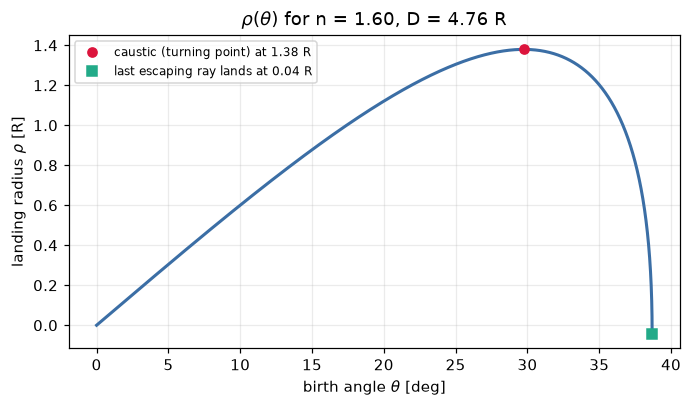

In [13]:
def landing_radius(theta, n, D):
    """Radius on the screen (units of R) hit by a ray born at angle theta."""
    theta = np.asarray(theta, dtype=float)
    phi = np.arcsin(np.clip(n * np.sin(theta), -1.0, 1.0))
    psi = 2.0 * theta - phi
    return np.sin(2 * theta) + (D - np.cos(2 * theta)) * np.tan(psi)

def rho_curve(n, D, m=40001):
    t = np.linspace(0.0, float(critical_angle(n)), m)
    return t, landing_radius(t, n, D)

t, rho = rho_curve(1.60, 4.76)
imax = int(np.argmax(np.abs(rho)))
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(np.degrees(t), rho, lw=2, color="#3b6ea5")
ax.plot(np.degrees(t[imax]), rho[imax], "o", color="crimson",
        label=f"caustic (turning point) at {rho[imax]:.2f} R")
ax.plot(np.degrees(t[-1]), rho[-1], "s", color="#2a8",
        label=f"last escaping ray lands at {abs(rho[-1]):.2f} R")
ax.set_xlabel(r"birth angle $\theta$ [deg]")
ax.set_ylabel(r"landing radius $\rho$ [R]")
ax.set_title(r"$\rho(\theta)$ for n = 1.60, D = 4.76 R")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


### 3.2 Why the picture has exactly two edges

Read the story straight off the shape of $\rho(\theta)$:

* $\rho$ starts at 0 (the on-axis ray), grows, **turns over**, and folds back.
* The turning point is a **caustic**: no direct ray can land beyond it. That is
  the crisp **outer edge of the halo**, measured at $1.380\,R$.
* Past the turning point the rays fold inwards, so the annulus between the last
  ray's landing radius and the caustic is covered by **two** ray families while
  the inner disc is covered by **one**. The folded family sweeps a huge range of
  $\rho$ over a tiny range of $\theta$, so it is faint - and the brightness
  therefore **steps down** exactly where it begins. That step is the **edge of the
  bright core**, measured at $0.288\,R$.

Two equations, two unknowns:

$$\max_\theta|\rho| = 1.380,\qquad |\rho(\theta_c)| = 0.288 .$$


In [15]:
def bisect(f, lo, hi, iters=60):
    flo, fhi = f(lo), f(hi)
    if flo is None or fhi is None or flo * fhi > 0:
        return None
    for _ in range(iters):
        mid = 0.5 * (lo + hi); fm = f(mid)
        if flo * fm <= 0: hi = mid
        else:             lo, flo = mid, fm
    return 0.5 * (lo + hi)

def D_for_halo(n, halo=HALO_EDGE):
    """Screen distance putting the caustic exactly at the measured halo edge."""
    return bisect(lambda D: float(np.nanmax(np.abs(rho_curve(n, D)[1]))) - halo,
                  1.0001, 400.0)

def core_edge(n):
    """With D fixed by the halo, where does the last escaping ray land?"""
    D = D_for_halo(n)
    return None if D is None else abs(float(rho_curve(n, D)[1][-1]))

print(f"{'n':>7}{'D / R':>9}{'core edge [R]':>15}{'f = sqrt(1-1/n^2)':>20}")
for n in np.arange(1.50, 1.70, 0.01):
    D = D_for_halo(float(n))
    if D is None:
        print(f"{n:7.3f}   -- no screen distance reproduces a 1.380 R edge --")
        continue
    ce = abs(float(rho_curve(float(n), D)[1][-1]))
    flag = "   <== matches 0.288" if abs(ce - CORE_EDGE) < 0.02 else ""
    print(f"{n:7.3f}{D:9.2f}{ce:15.3f}{float(f_theory(float(n))):20.3f}{flag}")


      n    D / R  core edge [R]   f = sqrt(1-1/n^2)
  1.500     2.69          0.706               0.745
  1.510     2.84          0.656               0.749
  1.520     3.00          0.603               0.753
  1.530     3.17          0.544               0.757
  1.540     3.35          0.480               0.760
  1.550     3.55          0.411               0.764
  1.560     3.76          0.335               0.768
  1.570     3.99          0.253               0.771
  1.580     4.23          0.163               0.774
  1.590     4.49          0.065               0.777
  1.600     4.76          0.043               0.781
  1.610     5.06          0.161               0.784
  1.620     5.39          0.290               0.787   <== matches 0.288
  1.630     5.74          0.432               0.790
  1.640     6.12          0.588               0.793
  1.650     6.53          0.760               0.795
  1.660     6.98          0.950               0.798
  1.670     7.47          1.159             

Two indices reproduce the measured core edge, one on each side of the dip (the
folded ray family sweeps through the axis near $n\approx1.60$ and comes back out
again). That is an unavoidable two-fold ambiguity of this measurement:

* $n \approx 1.57$, screen at $D\approx3.9\,R$
* $n \approx 1.62$, screen at $D\approx5.4\,R$

Both are thoroughly sensible glass indices - lead "crystal" glass lives exactly in
that window, $n\approx1.55$-$1.65$ - and, luckily, they give almost the same
answer.


In [17]:
sols = []
for lo, hi in ((1.550, 1.595), (1.605, 1.650)):
    grid = np.arange(lo, hi, 0.001)
    best = min(grid, key=lambda nn: abs((core_edge(float(nn)) or 9.0) - CORE_EDGE))
    sols.append((float(best), D_for_halo(float(best))))

print("Solutions consistent with BOTH measured radii\n")
for n, D in sols:
    t, rho = rho_curve(n, D)
    print(f"  n = {n:.3f}   D = {D:.2f} R   theta_c = {np.degrees(critical_angle(n)):.2f} deg")
    print(f"      halo edge modelled {np.nanmax(np.abs(rho)):.3f} R  (measured {HALO_EDGE})")
    print(f"      core edge modelled {abs(rho[-1]):.3f} R  (measured {CORE_EDGE})")
    print(f"      -> f_scattered = {float(f_theory(n)):.4f}\n")

f_lo, f_hi = sorted(float(f_theory(n)) for n, _ in sols)
print(f"answer bracket: {f_lo:.3f} .. {f_hi:.3f}   ->   f = {0.5*(f_lo+f_hi):.2f}")


Solutions consistent with BOTH measured radii

  n = 1.566   D = 3.89 R   theta_c = 39.69 deg
      halo edge modelled 1.380 R  (measured 1.38)
      core edge modelled 0.287 R  (measured 0.288)
      -> f_scattered = 0.7696

  n = 1.620   D = 5.39 R   theta_c = 38.12 deg
      halo edge modelled 1.380 R  (measured 1.38)
      core edge modelled 0.290 R  (measured 0.288)
      -> f_scattered = 0.7867

answer bracket: 0.770 .. 0.787   ->   f = 0.78


---

## Part 4 - Monte Carlo #2: re-render the photograph

A fit that matches two numbers could still be a fluke. The real test is to throw a
million photons through the ball and check that the *whole* image comes out right:
flat bright core, step, long fading halo, hard outer edge.

The sampling is the only subtle part. For an isotropic source the correct measure
is **uniform in $\cos\theta$**, not uniform in $\theta$; and when histogramming
the landing radii we must divide by the annulus area $2\pi\rho\,d\rho$ to turn
counts into *surface brightness*, which is what a screen actually shows.


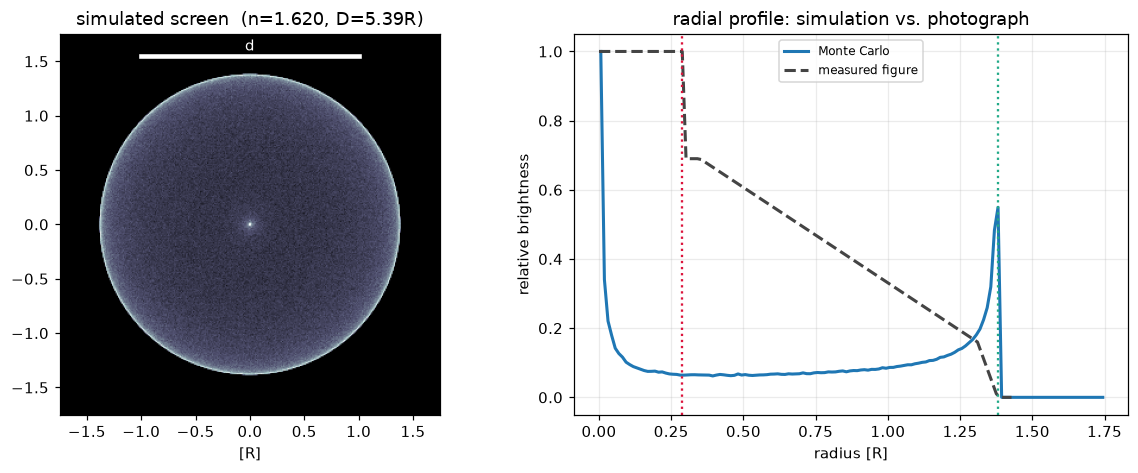

In [19]:
def render_screen(n, D, n_rays=1_000_000, r_max=1.75, n_bins=140, seed=3):
    """Monte-Carlo the direct light; return (radii, brightness, x, y)."""
    rng = np.random.default_rng(seed)
    tc = float(critical_angle(n))
    u = rng.uniform(np.cos(tc), 1.0, n_rays)     # isotropic within escape cone
    theta = np.arccos(u)
    phi = np.arcsin(np.clip(n * np.sin(theta), -1.0, 1.0))
    psi = 2.0 * theta - phi
    ok = np.abs(psi) < np.pi / 2 - 1e-9
    theta, psi = theta[ok], psi[ok]
    rho = np.abs(np.sin(2 * theta) + (D - np.cos(2 * theta)) * np.tan(psi))

    edges = np.linspace(0.0, r_max, n_bins + 1)
    counts, _ = np.histogram(rho, bins=edges)
    area = np.pi * (edges[1:] ** 2 - edges[:-1] ** 2)
    centres = 0.5 * (edges[1:] + edges[:-1])
    bright = counts / area
    az = rng.uniform(0, 2 * np.pi, rho.size)     # spin them about the axis
    return centres, bright / bright.max(), rho * np.cos(az), rho * np.sin(az)

n_fit, D_fit = sols[1]           # the n ~ 1.62 branch; the other looks the same
c, b, x, y = render_screen(n_fit, D_fit)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
H, xe, ye = np.histogram2d(x, y, bins=320, range=[[-1.75, 1.75], [-1.75, 1.75]])
axes[0].imshow(np.sqrt(H.T), origin="lower", cmap="bone",
               extent=[-1.75, 1.75, -1.75, 1.75])
axes[0].plot([-1.0, 1.0], [1.55, 1.55], color="white", lw=3)
axes[0].text(0, 1.60, "d", color="white", ha="center")
axes[0].set_title(f"simulated screen  (n={n_fit:.3f}, D={D_fit:.2f}R)")
axes[0].set_xlabel("[R]"); axes[0].grid(False)

axes[1].plot(c, b, lw=2, label="Monte Carlo")
axes[1].plot(r_meas, I_meas, lw=2, ls="--", color="#444", label="measured figure")
axes[1].axvline(CORE_EDGE, color="crimson", ls=":")
axes[1].axvline(HALO_EDGE, color="#2a8", ls=":")
axes[1].set_xlabel("radius [R]"); axes[1].set_ylabel("relative brightness")
axes[1].set_title("radial profile: simulation vs. photograph")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


The simulated screen reproduces the anatomy of the given figure: a compact bright
core with a sharp rim, a step down, a slow outward fade and a hard cut-off well
outside the ball's own silhouette. (The published figure is smoother because it is
a rendered, slightly blurred image, and because the real scattered light fills in
a background that we are not simulating here - we only trace the direct light for
the image.)

---

## Part 5 - The answer

Putting the two halves together:

* the picture pins the glass at $n = 1.57$-$1.62$;
* the physics says $f_{\text{scattered}} = \cos\theta_c = \sqrt{1-1/n^2}$.


In [21]:
print("=" * 62)
for n, D in sols:
    print(f"  n = {n:.3f} (screen at {D:.2f} R)  ->  f = {float(f_theory(n)):.4f}")
f_best = float(np.mean([float(f_theory(n)) for n, _ in sols]))
print("=" * 62)
print(f"  ANSWER:  f_scattered = {f_best:.2f}")
print(f"           about {100*f_best:.0f}% of the emitted energy leaves the ball")
print( "           as scattered light,")
print(f"           and only about {100*(1-f_best):.0f}% as direct light.")
print("=" * 62)

# final sanity check with the full photon tracer at the fitted index
f_mc, ev = trace_photons(sols[1][0], n_photons=2500, mfp=50.0, seed=99)
print(f"\nfull photon-tracing Monte Carlo at n = {sols[1][0]:.3f}:  f = {f_mc:.4f}")
print(f"average impurity scatterings before a trapped photon escapes: {ev:.1f}")


  n = 1.566 (screen at 3.89 R)  ->  f = 0.7696
  n = 1.620 (screen at 5.39 R)  ->  f = 0.7867
  ANSWER:  f_scattered = 0.78
           about 78% of the emitted energy leaves the ball
           as scattered light,
           and only about 22% as direct light.

full photon-tracing Monte Carlo at n = 1.620:  f = 0.7952
average impurity scatterings before a trapped photon escapes: 2.7


$$\boxed{f_{\text{scattered}} \approx 0.78 \ \ (\text{about } 78\%)}$$

### Why this is robust

The weakest link is reading $n$ off a small picture - but the answer barely cares.
The whole plausible range $n = 1.55$-$1.65$ gives $f = 0.76$-$0.80$, and even plain
crown glass ($n=1.50$) would only bring it down to $0.75$. The punchline is
completely safe:

> **Most of the light - roughly three quarters to four fifths of it - never gets
> out directly. It is trapped by total internal reflection and escapes only
> because impurities eventually scatter it.**

### The one-paragraph summary

Because the source sits *on* the sphere, its angle of incidence is a conserved
quantity, so total internal reflection is an all-or-nothing sentence passed at
birth. With no absorption and a perfect AR coating, everything trapped must leave
later as scattered light, so the answer is simply the solid-angle fraction beyond
the critical angle, $\cos\theta_c=\sqrt{1-1/n^2}$. The picture supplies $n$: the
halo edge is a caustic at $1.38\,R$ and the bright core's rim is where the last
escaping ray lands at $0.288\,R$; matching both fixes $n\approx1.6$ with the
screen a few ball-radii away. Hence $f\approx0.78$.

---

*Companion file: `crystal_ball_solution.py` - the same physics as a plain,
runnable script.*
